# 06 - Spherical harmonics: view-dependent color

The next artifact this project wants to render is a real scene trained by
the official 3DGS pipeline, shipped as a `.ply`. Count its color fields:
`f_dc_0..2` plus `f_rest_0..44`, 48 floats per splat. Our renderer accepts
three. This notebook builds the decoder for the other 45.

The 48 numbers exist because captured reality is view-dependent. A glossy
table shows a window highlight from one chair and plain wood from the next;
varnish, screens, skin, brushed metal all shift with viewpoint. One RGB
triple asserts that a splat looks identical from everywhere. On real
captures that assertion costs the highlights: the training views disagree
about the color, and a single RGB can only store something like their
average.

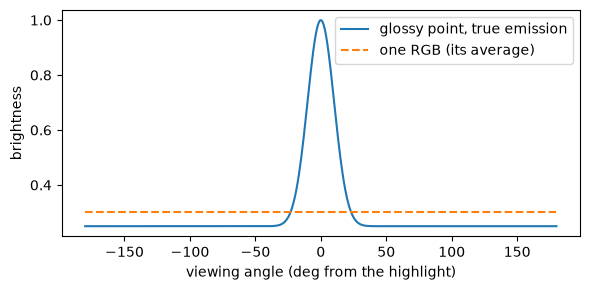

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gsplat_edu import Camera, render_gaussians, sphere_shell

# what a glossy point emits, versus the best a single RGB can say
ang = np.linspace(-np.pi, np.pi, 400)
glossy = 0.25 + 0.75 * np.maximum(np.cos(ang), 0.0) ** 32
flat = np.full_like(ang, glossy.mean())

plt.figure(figsize=(6, 3))
plt.plot(np.degrees(ang), glossy, label="glossy point, true emission")
plt.plot(np.degrees(ang), flat, ls="--", label="one RGB (its average)")
plt.xlabel("viewing angle (deg from the highlight)")
plt.ylabel("brightness")
plt.legend(); plt.tight_layout(); plt.show()

The dashed line is the break: every viewpoint gets the average, the
highlight is gone. The fix is a color that is a function of direction,
stored in a few coefficients. First, which direction.

## View direction, per splat

$$d = \frac{\mu - \text{eye}}{\lVert \mu - \text{eye} \rVert}$$

One direction per splat per frame, taken at the mean. Pixels inside a
splat's footprint see slightly different true directions; the official
renderer computes color once per splat in its preprocess step with this
same approximation, and we inherit it.

In [2]:
means, cov3ds, base_colors, opacities = sphere_shell()
cam = Camera.looking_at(eye=[0, 0, -3], target=[0, 0, 0],
                        fx=600, fy=600, H=512, W=512)

def view_dirs(means, cam):
    d = means - cam.eye
    return d / np.linalg.norm(d, axis=-1, keepdims=True)

dirs = view_dirs(means, cam)
assert np.allclose(np.linalg.norm(dirs, axis=-1), 1.0)
print(dirs.shape, "unit view directions")

(2500, 3) unit view directions


## The basis

A view-dependent color is a function on the unit sphere, one per channel.
The representation the whole field uses is a truncated spherical harmonic
expansion: polynomials in the direction components $(x, y, z)$, organized
in degree bands $l = 0 \ldots 3$ with $2l + 1$ functions per band, 16
functions
total. Low degrees are smooth, wide lobes; each added band buys sharper
directional detail. The coefficients are the stored numbers: 16 per
channel, 48 per splat, exactly the ply's color fields.

The constants below, and the signs in the evaluation, are the ones the
entire GS ecosystem shares (`computeColorFromSH` in the official CUDA).
A trained ply decodes only under exactly this convention:

```
deg 0: c  = C0*sh[0]
deg 1: c += -C1*y*sh[1] + C1*z*sh[2] - C1*x*sh[3]
deg 2: c += C2[0]*x*y*sh[4] + C2[1]*y*z*sh[5]
          + C2[2]*(2z^2 - x^2 - y^2)*sh[6]
          + C2[3]*x*z*sh[7] + C2[4]*(x^2 - y^2)*sh[8]
deg 3: c += C3[0]*y*(3x^2 - y^2)*sh[9] + C3[1]*x*y*z*sh[10]
          + C3[2]*y*(4z^2 - x^2 - y^2)*sh[11]
          + C3[3]*z*(2z^2 - 3x^2 - 3y^2)*sh[12]
          + C3[4]*x*(4z^2 - x^2 - y^2)*sh[13]
          + C3[5]*z*(x^2 - y^2)*sh[14] + C3[6]*x*(x^2 - 3y^2)*sh[15]
final: color = clip(c + 0.5, 0, None)
```

The `+ 0.5` offset centers the decode: an all-zero coefficient vector is
middle gray, and training starts near it. The clip only guards the floor;
nothing stops a decoded color from exceeding 1.

In [3]:
C0 = 0.28209479177387814
C1 = 0.4886025119029199
C2 = [1.0925484305920792, -1.0925484305920792, 0.31539156525252005,
      -1.0925484305920792, 0.5462742152960396]
C3 = [-0.5900435899266435, 2.890611442640554, -0.4570457994644658,
      0.3731763325901154, -0.4570457994644658, 1.445305721320277,
      -0.5900435899266435]

def sh_basis(dirs):
    """Basis values at unit directions. dirs (..., 3) -> (..., 16)."""
    dirs = np.asarray(dirs, float)
    x, y, z = dirs[..., 0], dirs[..., 1], dirs[..., 2]
    xx, yy, zz = x * x, y * y, z * z
    xy, yz, xz = x * y, y * z, x * z
    b = np.empty(dirs.shape[:-1] + (16,))
    b[..., 0] = C0
    b[..., 1] = -C1 * y
    b[..., 2] = C1 * z
    b[..., 3] = -C1 * x
    b[..., 4] = C2[0] * xy
    b[..., 5] = C2[1] * yz
    b[..., 6] = C2[2] * (2 * zz - xx - yy)
    b[..., 7] = C2[3] * xz
    b[..., 8] = C2[4] * (xx - yy)
    b[..., 9] = C3[0] * y * (3 * xx - yy)
    b[..., 10] = C3[1] * xy * z
    b[..., 11] = C3[2] * y * (4 * zz - xx - yy)
    b[..., 12] = C3[3] * z * (2 * zz - 3 * xx - 3 * yy)
    b[..., 13] = C3[4] * x * (4 * zz - xx - yy)
    b[..., 14] = C3[5] * z * (xx - yy)
    b[..., 15] = C3[6] * x * (xx - 3 * yy)
    return b

def eval_sh(deg, sh, dirs):
    """Decode SH coefficients to RGB at unit view directions.

    sh (N, K, 3) with K >= (deg+1)^2, dirs (N, 3). Returns (N, 3),
    clip(sum_i b_i(d) sh_i + 0.5, 0, None).
    """
    k = (deg + 1) ** 2
    sh = np.asarray(sh, float)
    assert sh.shape[-2] >= k, f"need {k} coefficients for degree {deg}"
    b = sh_basis(dirs)[..., :k]
    c = np.einsum("...k,...kc->...c", b, sh[..., :k, :])
    return np.clip(c + 0.5, 0.0, None)

## Checking the constants before trusting them

These sixteen functions are orthonormal on the sphere:
`integral(b_i b_j dA) = delta_ij`. That is a property of the exact
constants, so it doubles as a test of them. Estimate every integral by
Monte Carlo over uniform directions: with `N` samples the estimate is
`(4 pi / N) B^T B`, and at 200k samples it should sit within a couple
percent of the identity matrix. A wrong constant breaks a diagonal entry;
a corrupted polynomial (a sign slip inside a formula, a swapped component)
breaks an off-diagonal one.

One error class survives that test: flipping the sign of an entire basis
function keeps the matrix identical, because it only ever appears squared
or against functions it integrates to zero with. The overall signs are
convention, so they get pinned the direct way: evaluate at the axis
directions and compare with values read off the formula block above.

In [4]:
rng = np.random.default_rng(6)
samples = rng.normal(size=(200_000, 3))
samples /= np.linalg.norm(samples, axis=-1, keepdims=True)

B = sh_basis(samples)
gram = (4 * np.pi / len(samples)) * (B.T @ B)
dev = np.abs(gram - np.eye(16)).max()
print(f"max |gram - I| = {dev:.4f}")
assert dev < 0.03

# axis spot checks against the formula block, all 16 entries each
bx = np.zeros(16); bx[0] = C0; bx[3] = -C1; bx[6] = -C2[2]
bx[8] = C2[4]; bx[13] = -C3[4]; bx[15] = C3[6]
by = np.zeros(16); by[0] = C0; by[1] = -C1; by[6] = -C2[2]
by[8] = -C2[4]; by[9] = -C3[0]; by[11] = -C3[2]
bz = np.zeros(16); bz[0] = C0; bz[2] = C1; bz[6] = 2 * C2[2]
bz[12] = 2 * C3[3]
for d, expected in [([1, 0, 0], bx), ([0, 1, 0], by), ([0, 0, 1], bz)]:
    assert np.allclose(sh_basis(np.array(d, float)), expected)

# degree 0 is direction-independent: same coefficients, different
# directions, identical colors
sh_rand = rng.normal(size=(50, 16, 3))
d1 = samples[:50]; d2 = samples[50:100]
assert np.array_equal(eval_sh(0, sh_rand, d1), eval_sh(0, sh_rand, d2))

# the clip floors the decode at zero
sh_dark = np.zeros((1, 16, 3)); sh_dark[0, 0] = -10.0
assert np.array_equal(eval_sh(3, sh_dark, d1[:1]), np.zeros((1, 3)))

print("orthonormality, axis signs, deg-0 constancy, clip: all hold")

max |gram - I| = 0.0069
orthonormality, axis signs, deg-0 constancy, clip: all hold


## What the sixteen functions look like

Each panel maps a basis function over the whole sphere of directions
(azimuth across, polar angle down), red positive, blue negative. Band
`l = 0` is constant, band 1 holds the three axis tilts, and each band
down the pyramid oscillates one step faster across the sphere.

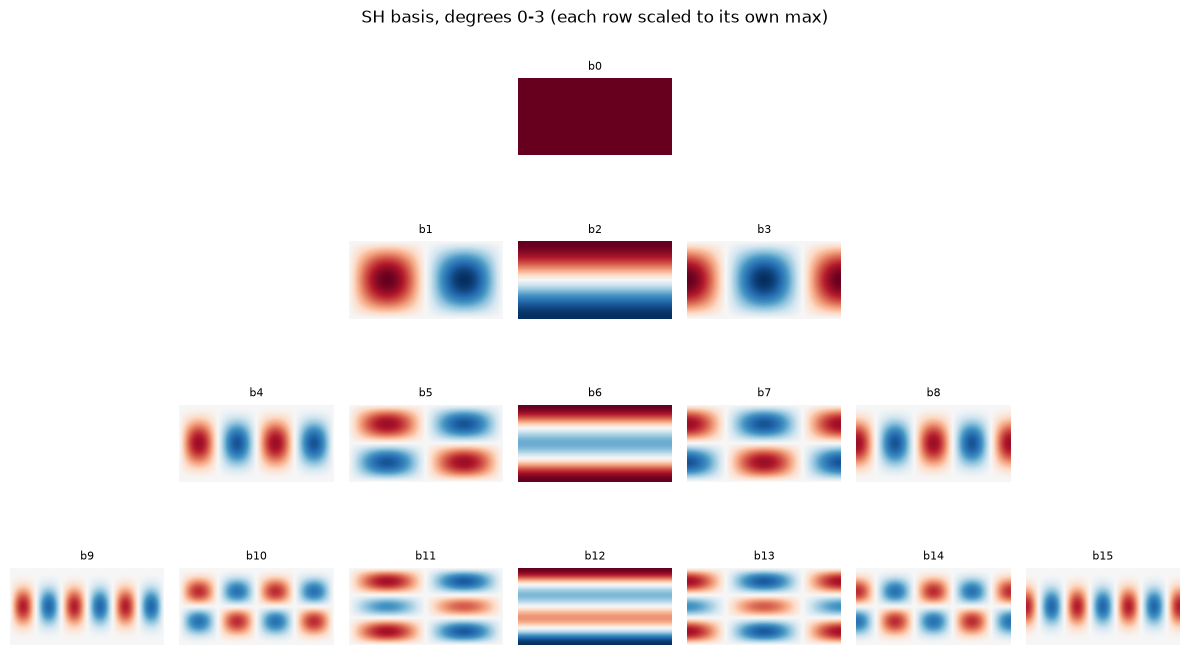

In [5]:
phi, theta = np.meshgrid(np.linspace(-np.pi, np.pi, 240),
                         np.linspace(0, np.pi, 120))
grid_dirs = np.stack([np.sin(theta) * np.cos(phi),
                      np.sin(theta) * np.sin(phi),
                      np.cos(theta)], axis=-1)
Bgrid = sh_basis(grid_dirs)

fig, axes = plt.subplots(4, 7, figsize=(12, 7))
for ax in axes.ravel():
    ax.axis("off")
i = 0
for l in range(4):
    row = axes[l]
    lo = (7 - (2 * l + 1)) // 2
    vmax = np.abs(Bgrid[..., l * l:(l + 1) ** 2]).max()
    for m in range(2 * l + 1):
        ax = row[lo + m]
        ax.imshow(Bgrid[..., i], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"b{i}", fontsize=8)
        i += 1
fig.suptitle("SH basis, degrees 0-3 (each row scaled to its own max)")
plt.tight_layout()
plt.show()

The four functions down the pyramid's center line depend only on `z`, so a
slice through the x-z plane shows their lobes as polar plots: radius is
the magnitude, color the sign. These profiles are the classic SH pictures.

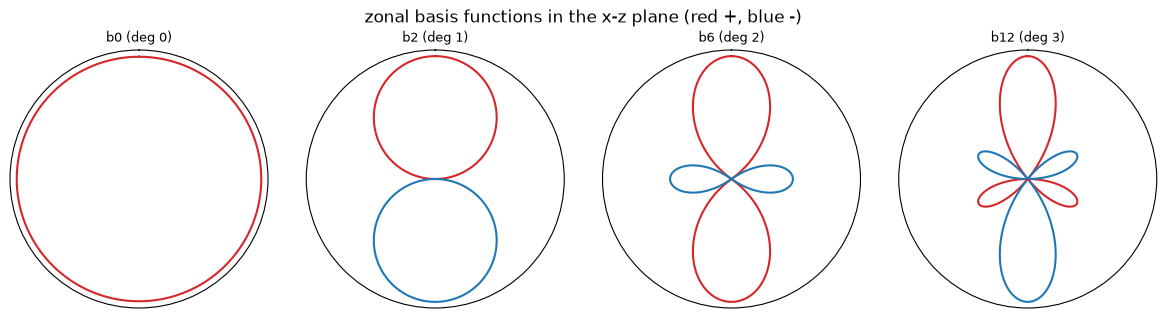

In [6]:
t = np.linspace(0, 2 * np.pi, 400)
slice_dirs = np.stack([np.sin(t), np.zeros_like(t), np.cos(t)], axis=-1)
Bslice = sh_basis(slice_dirs)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2),
                         subplot_kw={"projection": "polar"})
for deg, (ax, i) in enumerate(zip(axes, [0, 2, 6, 12])):
    val = Bslice[:, i]
    for sign, color in [(val >= 0, "tab:red"), (val < 0, "tab:blue")]:
        ax.plot(np.where(sign, t, np.nan), np.abs(val), color=color)
    ax.set_title(f"b{i} (deg {deg})", fontsize=9)
    ax.set_theta_zero_location("N")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("zonal basis functions in the x-z plane (red +, blue -)")
plt.tight_layout()
plt.show()

## Exercise

Author two coefficient arrays by hand, both shape `(16, 3)` and degree 1.
First: a splat that decodes to exact middle gray `(0.5, 0.5, 0.5)` from
every direction. Second: a splat that reads redder from `+x` and bluer
from `-x`, symmetric about gray, green untouched. Which entries are
nonzero, and with which signs? The degree-1 line of the evaluation block
has the answer in it. Verify numerically before scrolling.

## Solution

Middle gray is the all-zero array: the decode's `+ 0.5` offset supplies it,
and that is precisely why the offset exists.

The `x` dependence enters through `sh[3]` with basis value `-C1 x`. A red
channel `0.5 + k x` therefore needs `sh[3] = -k / C1` in red, and blue gets
the opposite sign. The minus sign is the convention pinned by the axis
checks above; author coefficients without respecting it and the colors
come out mirrored.

In [7]:
gray = np.zeros((1, 16, 3))
assert np.allclose(eval_sh(1, gray, samples[:500]), 0.5)

k = 0.25
tinted = np.zeros((1, 16, 3))
tinted[0, 3, 0] = -k / C1   # red rises along +x
tinted[0, 3, 2] = +k / C1   # blue falls along +x

plus_x = np.array([[1.0, 0.0, 0.0]])
assert np.allclose(eval_sh(1, tinted, plus_x), [[0.75, 0.5, 0.25]])
assert np.allclose(eval_sh(1, tinted, -plus_x), [[0.25, 0.5, 0.75]])
print("gray from zeros, red toward +x, blue toward -x")

gray from zeros, red toward +x, blue toward -x


One splat, one orbit of view directions in the x-z plane, decoded per
direction. The strip below the curves is the color itself.

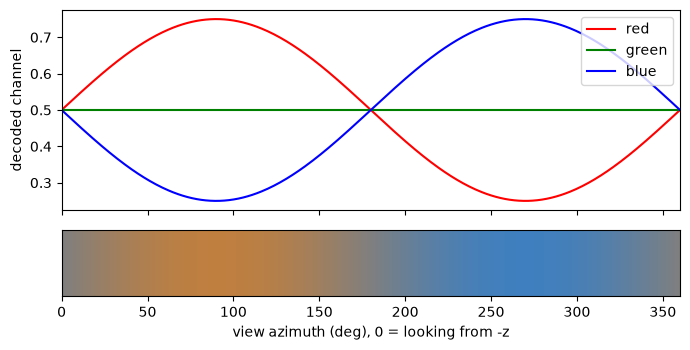

In [8]:
orbit = np.stack([np.sin(t), np.zeros_like(t), np.cos(t)], axis=-1)
c_orbit = eval_sh(1, np.repeat(tinted, len(orbit), 0), orbit)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 3.6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
for ch, name in enumerate(["red", "green", "blue"]):
    ax0.plot(np.degrees(t), c_orbit[:, ch], color=name, label=name)
ax0.set_ylabel("decoded channel"); ax0.legend(loc="upper right")
ax1.imshow(np.clip(c_orbit, 0, 1)[None, :, :], aspect="auto",
           extent=[0, 360, 0, 1])
ax1.set_yticks([]); ax1.set_xlabel("view azimuth (deg), 0 = looking from -z")
plt.tight_layout()
plt.show()

## Projecting a real lobe onto the basis

Orthonormality earned its Monte Carlo check above; here is what it buys.
For an orthonormal basis, the truncated expansion that minimizes squared
error has coefficients given by projection:

$$c_i = \int_{S^2} f(d)\, b_i(d)\, dA
\;\approx\; \frac{4\pi}{N} \sum_{n} f(d_n)\, b_i(d_n)$$

Take a synthetic sheen, a Phong-style lobe around a fixed world direction
`L`, and project it:

$$f(d) = 0.45 \, \max(d \cdot L, 0)^{4}$$

More bands, better fit. The residual must drop as each band is added, and
the assert holds the projection formula to that.

deg 0: rms residual 0.0964
deg 1: rms residual 0.0710
deg 2: rms residual 0.0414
deg 3: rms residual 0.0178


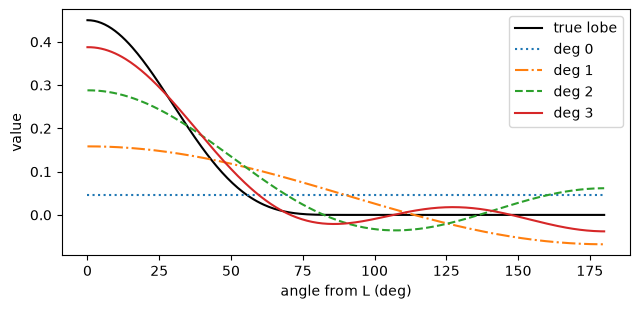

In [9]:
L = np.array([-1.0, 0.0, 0.0])   # the sheen faces the azimuth-90 camera
f = 0.45 * np.maximum(samples @ L, 0.0) ** 4
lobe = (4 * np.pi / len(samples)) * (B.T @ f)

errs = []
for deg in range(4):
    kk = (deg + 1) ** 2
    errs.append(np.sqrt(np.mean((B[:, :kk] @ lobe[:kk] - f) ** 2)))
    print(f"deg {deg}: rms residual {errs[-1]:.4f}")
assert all(e1 < e0 for e0, e1 in zip(errs, errs[1:]))

ang_from_L = np.linspace(0, np.pi, 300)
arc = np.stack([-np.cos(ang_from_L), np.zeros_like(ang_from_L),
                np.sin(ang_from_L)], axis=-1)
Barc = sh_basis(arc)
plt.figure(figsize=(6.5, 3.2))
plt.plot(np.degrees(ang_from_L),
         0.45 * np.maximum(arc @ L, 0.0) ** 4, "k", label="true lobe")
for deg, style in zip(range(4), [":", "-.", "--", "-"]):
    kk = (deg + 1) ** 2
    plt.plot(np.degrees(ang_from_L), Barc[:, :kk] @ lobe[:kk],
             style, label=f"deg {deg}")
plt.xlabel("angle from L (deg)"); plt.ylabel("value")
plt.legend(); plt.tight_layout(); plt.show()

Degree 0 is the flat average from the opening figure. Degree 3 tracks the
lobe, and the shallow dip it swings below zero near 90 degrees is the
signature of a truncated basis fitting a kink; the decode's clip floors
it in color space. Sixteen numbers per channel buy exactly this much
sharpness and no more, which is why 3DGS highlights read as sheen rather
than mirror reflections.

## The toy sphere, now with a sheen

Coefficients for the whole scene: the degree-0 slot carries each splat's
base color (divide out `C0` and the offset), and every splat gets the
same white lobe added on top, the way a glossy coating sits on top of an
albedo. The renderer does not change at all: decode first, then pass
plain RGB in.

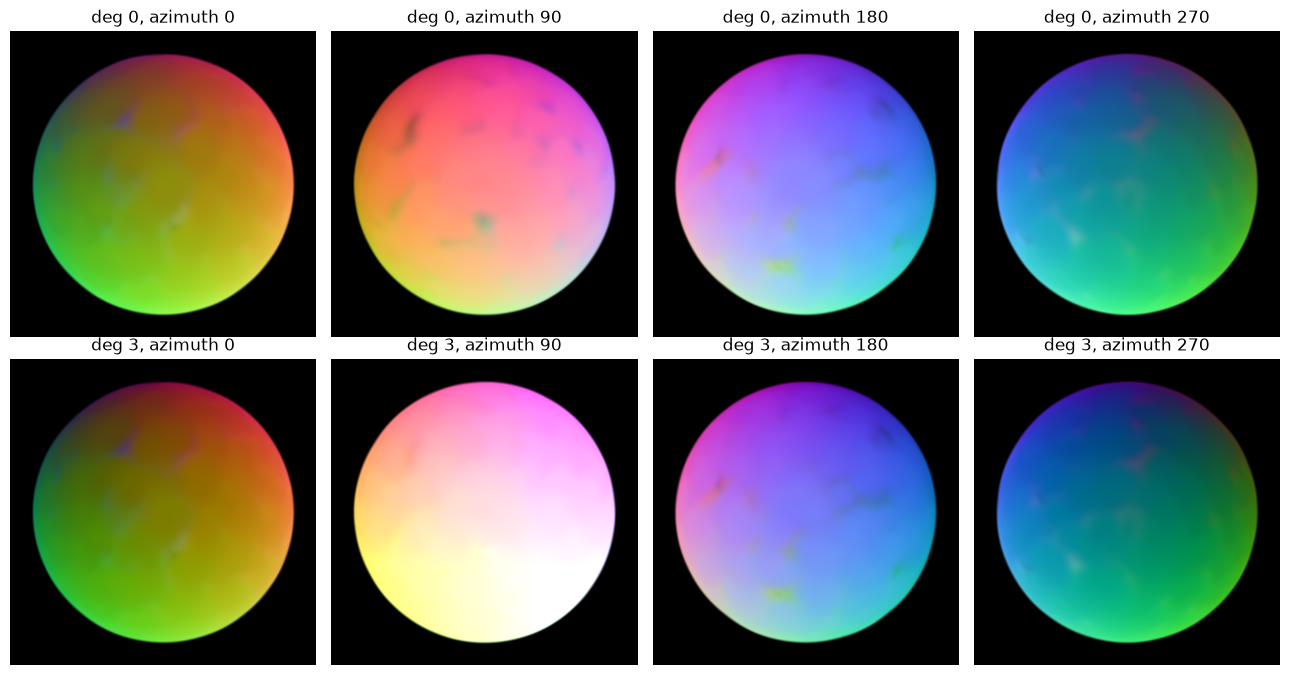

In [10]:
sh_scene = np.zeros((len(means), 16, 3))
sh_scene[:, 0, :] = (base_colors - 0.5) / C0
sh_scene += lobe[None, :, None]          # white sheen, same in R, G, B

azimuths = [0, 90, 180, 270]
fig, axes = plt.subplots(2, 4, figsize=(13, 6.8))
for col, az in enumerate(azimuths):
    a = np.radians(az)
    c = Camera.looking_at(eye=[3 * np.sin(a), 0, -3 * np.cos(a)],
                          target=[0, 0, 0], fx=600, fy=600, H=512, W=512)
    d = view_dirs(means, c)
    for row, deg in enumerate([0, 3]):
        img, _ = render_gaussians(c, means, cov3ds,
                                  eval_sh(deg, sh_scene, d), opacities)
        axes[row, col].imshow(np.clip(img, 0, 1))
        axes[row, col].set_title(f"deg {deg}, azimuth {az}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

The top row is the break, restated. Colors still change across it, because
the orbit exposes different hemispheres of a surface whose albedo varies
from splat to splat; that is geometry, and flat RGB handles it fine. What
degree 0 cannot do is make any single splat answer differently to two
cameras: the lobe survives only as its average, a faint uniform haze over
all four views. The bottom row is the fix. At azimuth 90 the camera looks
straight along `L` and a white glare washes over the sphere; one view
earlier or later it is already gone, exactly as the `cos^4` profile says
it should be. Same splats, same 48 numbers each, and the appearance now
follows the camera.

## Promotion

`sh_basis` and `eval_sh` move to the package as `gsplat_edu.sh`, constants
included. The renderer stays color-agnostic: callers decode, then hand
`render_gaussians` plain RGB, exactly as the montage cell did. Prove the
package matches this notebook to the bit:

In [11]:
import gsplat_edu

sh_test = rng.normal(size=(300, 16, 3))
d_test = rng.normal(size=(300, 3))
d_test /= np.linalg.norm(d_test, axis=-1, keepdims=True)
assert np.array_equal(sh_basis(d_test), gsplat_edu.sh_basis(d_test))
for deg in range(4):
    assert np.array_equal(eval_sh(deg, sh_test, d_test),
                          gsplat_edu.eval_sh(deg, sh_test, d_test))
print("package sh matches the notebook, bit for bit")

package sh matches the notebook, bit for bit


## The next live problem

The decoder for a trained ply's 48 color numbers now exists, and it was
the only genuinely new math the file demands. Everything else in there is
packaging: 62 fields per splat in a fixed order, log-scales and opacity
logits that need their activations, wxyz quaternions, and a few hundred
thousand splats aimed at a renderer that measures its throughput in
seconds. Notebook 07 opens the file, decodes all of it, and renders a
photographed room with the code this project has built so far.